## Лабораторная работа №6
### Компьютерное зрение

**Выполнил:** Изгородин Илья Юрьевич  
**Группа:** ФИТ-232  
**Факультет:** ФИТиКС ОмГТУ  

*Омск, 2026*

Перед началом выполнения работы импотрирую библиотеки, необходимые для поставленных заданий

In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda')

# 1 Задание. CNN локализация лицевых точек.

Для удобства настраиваю конфиг, чтобы можно было централизованно управлять разными запусками 

In [2]:
CFG = {
    'data_path': 'data/1facial/training.csv',
    'img_size': 96,
    'batch_size': 64,
    'epochs': 12,
    'num_keypoints': 10,
    'subsample': 100000,
    'lr': 5e-4,
    'val_split': 0.2
}

Готовлю датасет и даталоадер с данными

In [3]:
class FaceKeypointsDataset(Dataset):
    def __init__(self, csv_path, transform=None, subsample=None):
        df = pd.read_csv(csv_path)
        if subsample: df = df.iloc[:subsample]
        
        self.images, self.keypoints = [], []
        for _, row in df.iterrows():
            try:
                pixels = np.array(row['Image'].split(), dtype=np.float32).reshape(96,96)
                kps = row.drop(['Image']).values.astype(np.float32)
                self.images.append(pixels)
                self.keypoints.append(kps)
            except:
                continue 
                
        self.transform = transform
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.FloatTensor(img).unsqueeze(0) / 255.

        kps = torch.FloatTensor(self.keypoints[i])
        return img, kps

In [4]:
def get_loaders(cfg):
    tf_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(10, translate=(0.1,0.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    dataset = FaceKeypointsDataset(cfg['data_path'], transform=tf_train, subsample=cfg['subsample'])
    val_len = int(len(dataset) * cfg['val_split'])
    train_ds, val_ds = random_split(dataset, [len(dataset)-val_len, val_len])
    val_ds.dataset.transform = tf_test
    
    return DataLoader(train_ds, cfg['batch_size'], True), DataLoader(val_ds, cfg['batch_size'])

Готовлю CNN модель для определения ключевых лицевых точек

In [5]:
class KeypointCNN(nn.Module):
    def __init__(self, num_keypoints=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(), nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_keypoints*2))
    def forward(self, x): return self.net(x)

Оглашаю функцию обучения

In [6]:
def train_epoch(model, loader, optimizer, criterion, device, mask_missing=True):
    model.train(); total_loss, total = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        mask = ~torch.isnan(y)
        if mask_missing and mask.any():
            loss = criterion(out[mask], y[mask])
        else:
            y_clean = y.clone(); y_clean[torch.isnan(y_clean)] = 0
            loss = criterion(out, y_clean)
        loss.backward(); optimizer.step()
        total_loss += loss.item(); total += y.size(0)
    return total_loss/len(loader)

Оглашаю функцию валидации

In [7]:
def validate(model, loader, criterion, device):
    model.eval(); total_loss, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            mask = ~torch.isnan(y)
            if mask.any():
                loss = criterion(out[mask], y[mask])
            else:
                loss = torch.tensor(0., device=device)
            total_loss += loss.item(); total += y.size(0)
    return total_loss/len(loader) if total > 0 else 0

Оглашаю функцию запуска эксперимента со сбором всех результатов

In [8]:
def run_experiment(name, model, train_ld, val_ld, cfg, optimizer_cls, use_scheduler=False, patience=4):
    model = model.to(device)
    optimizer = optimizer_cls(model.parameters(), lr=cfg['lr'])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5) if use_scheduler else None
    criterion = nn.MSELoss()
    
    history = {'train_loss':[], 'val_loss':[]}
    best_val_loss = float('inf')
    best_state = None
    wait = 0

    epoch_bar = tqdm(range(cfg['epochs']), desc=f'{name}', leave=True)
    
    for epoch in epoch_bar:
        tl = train_epoch(model, train_ld, optimizer, criterion, device)
        vl = validate(model, val_ld, criterion, device)
        if scheduler: scheduler.step()
        
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
            msg = f"Train: {tl:.2f} | Val: {vl:.2f} !best!"
        else:
            wait += 1
            msg = f"Train: {tl:.2f} | Val: {vl:.2f} (Wait: {wait}/{patience})"
            if wait >= patience:
                break
        
        epoch_bar.set_postfix_str(msg)
        
    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    return {'name': name, 'model': model, 'train_loss': history['train_loss'][-1], 'val_loss': history['val_loss'][-1], 'history': history}

Готовлю данные

In [9]:
train_ld, val_ld = get_loaders(CFG)
print(f"Train: {len(train_ld.dataset)}, Val: {len(val_ld.dataset)}")

Train: 5640, Val: 1409


Готовлю предобученную модель

In [10]:
def get_resnet18_kp():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
    m.fc = nn.Linear(m.fc.in_features, 30)
    return m

Запускаю эксперименты со сбором результатов

In [11]:
experiments = []
for opt_name, opt_cls in [('SGD', optim.SGD), ('Adam', optim.Adam), ('RMSprop', optim.RMSprop)]:
    experiments.append(run_experiment(f'Custom+{opt_name}', KeypointCNN(), train_ld, val_ld, CFG, opt_cls))

experiments.append(run_experiment('Custom+Adam+Scheduler', KeypointCNN(), train_ld, val_ld, CFG, optim.Adam, use_scheduler=True))
experiments.append(run_experiment('Custom+SGD+Augment', KeypointCNN(), train_ld, val_ld, CFG, optim.SGD))
experiments.append(run_experiment('ResNet18+Adam', get_resnet18_kp(), train_ld, val_ld, CFG, optim.Adam))

ResNet18+Adam: 100%|██████████| 12/12 [00:18<00:00,  1.53s/it, Train: 7.70 | Val: 10.47 !best!]     


Вывожу результаты

In [12]:
pd.DataFrame([{
    'Experiment': e['name'],
    'Train Loss': f"{e['train_loss']:.4f}",
    'Val Loss': f"{e['val_loss']:.4f}"
} for e in experiments]).sort_values('Val Loss', ascending=True)

,Experiment,Train Loss,Val Loss
5,ResNet18+Adam,7.7028,10.4673
4,Custom+SGD+Augment,31.2494,14.6456
1,Custom+Adam,24.3299,14.6961
3,Custom+Adam+Scheduler,24.3760,15.6682
0,Custom+SGD,32.0783,20.9310
2,Custom+RMSprop,23.1374,22.2503


Определяю лучшую модель

In [13]:
best = min(experiments, key=lambda x: x['val_loss'])
print(f"Best: {best['name']} | Val Loss: {best['val_loss']:.4f}")

Best: ResNet18+Adam | Val Loss: 10.4673


Вывожу график обучения

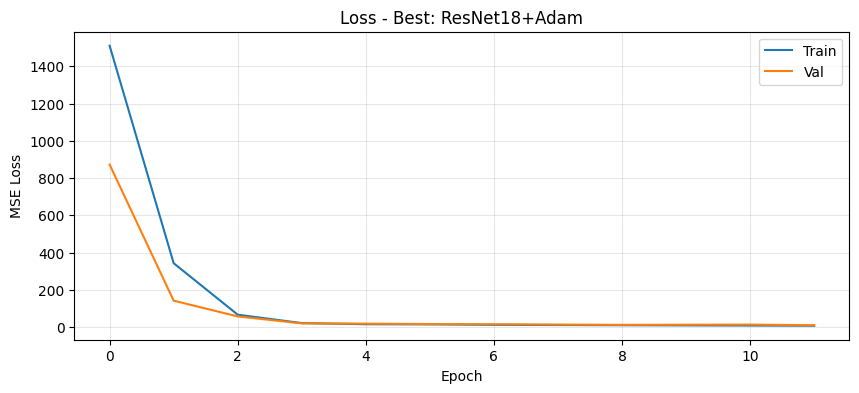

In [14]:
h = best['history']
plt.figure(figsize=(10,4))
plt.plot(h['train_loss'], label='Train'); plt.plot(h['val_loss'], label='Val')
plt.title(f"Loss - Best: {best['name']}"); plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

Оглашаю функцию визуализации предсказаний

In [15]:
def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(2, num_samples, figsize=(16, 8))
    with torch.no_grad():
        for i in range(num_samples):
            X, y = dataset[i]
            X = X.unsqueeze(0).to(device)
            pred = model(X).cpu().numpy().reshape(-1, 2)
            gt = y.numpy().reshape(-1, 2)
            
            img = (X[0, 0].cpu().numpy() * 0.5) + 0.5
            
            axes[0, i].imshow(img, cmap='gray'); axes[0, i].set_title(f'Sample {i}'); axes[0, i].axis('off')
            axes[1, i].imshow(img, cmap='gray')
            
            for k in range(15):
                if not np.isnan(gt[k, 0]):
                    axes[1, i].plot(gt[k, 0], gt[k, 1], 'go', markersize=8, alpha=0.8)
                    axes[1, i].plot(pred[k, 0], pred[k, 1], 'r.', markersize=6)
            axes[1, i].set_title('Pred(Red)/GT(Green)'); axes[1, i].axis('off')
    plt.tight_layout(); plt.show()

Оглашаю функцию визуализации фильторв

In [16]:
def visualize_filters_ascent(model, device, layer_idx=0, num_filters=16, steps=200, lr=0.1, input_size=96):
    model.train()
    for p in model.parameters():
        p.requires_grad = False

    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    target = convs[layer_idx]
    acts = {}
    hook = target.register_forward_hook(lambda m, i, o: acts.update({'out': o}))

    n_ch = target.out_channels
    cols, rows = 4, (min(num_filters, n_ch) + 3) // 4
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows*3))
    axes = axes.flatten() if num_filters > 1 else [axes]

    for f in range(min(num_filters, n_ch)):
        img = torch.randn(1, 1, input_size, input_size, device=device) * 0.1
        img.requires_grad_(True)
        optimizer = optim.Adam([img], lr=lr)

        for step in range(steps):
            optimizer.zero_grad()
            _ = model(img)
            loss = -torch.mean(acts['out'][0, f])

            tv = (torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]).sum() +
                  torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]).sum())
            l2 = torch.sum(img**2)
            loss = loss + 1e-4 * tv + 1e-5 * l2

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                img.clamp_(-1.0, 1.0)

        disp = img.detach().cpu().numpy()[0, 0]
        disp = (disp * 0.5) + 0.5
        axes[f].imshow(disp, cmap='gray')
        axes[f].set_title(f'Filter {f}')
        axes[f].axis('off')

    hook.remove()
    plt.tight_layout()
    plt.show()

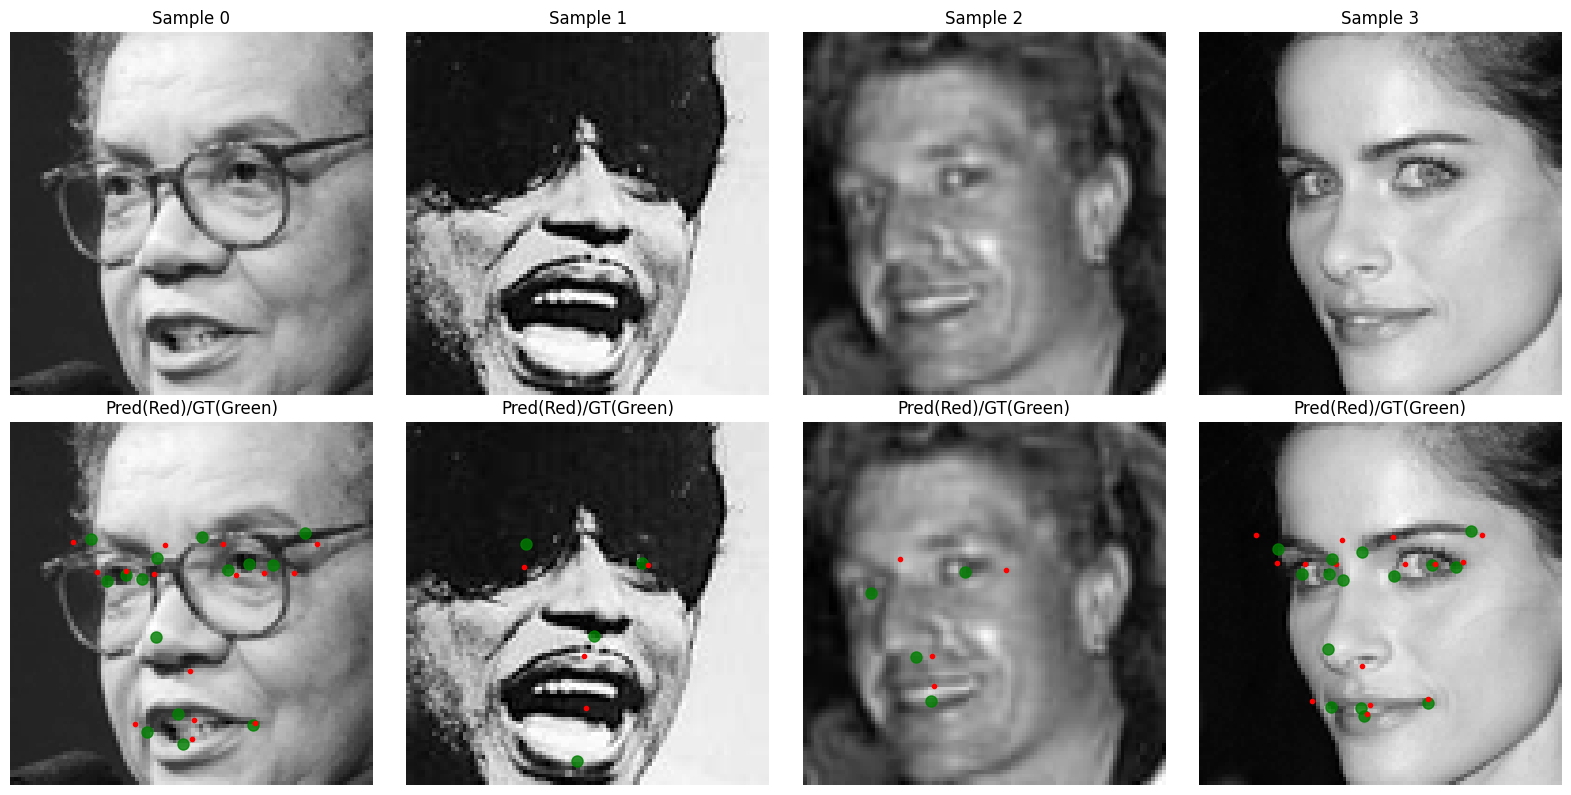

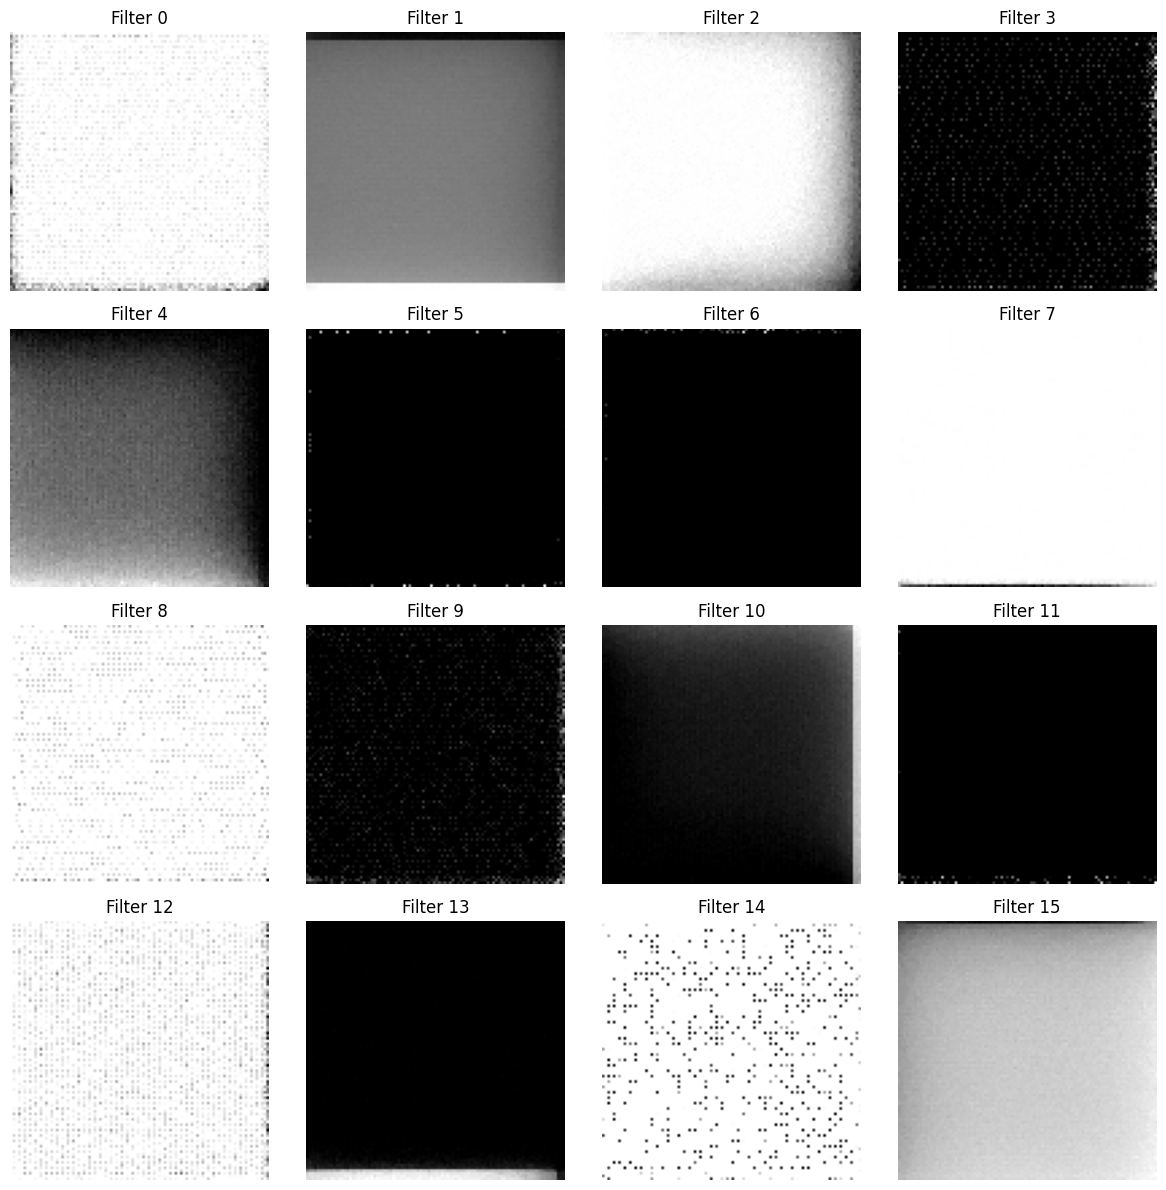

In [17]:
visualize_predictions(best['model'], val_ld.dataset, device)
visualize_filters_ascent(best['model'], device, layer_idx=0, num_filters=16)

# Задание 2. CNN Сегментация изображений.

Аналогично первому заданию собираю конфиг

In [35]:
CFG = {
    'data_root': 'data/2drone/dataset/semantic_drone_dataset', 
    'img_size': 256,
    'batch_size': 64,
    'epochs': 10,
    'num_classes': 11, 
    'subsample': 400,
    'lr': 4e-3
}

Готовлю датасет и даталоадеры с данными

In [36]:
class DroneSegDataset(Dataset):
    def __init__(self, root, transform=None, target_transform=None, subsample=None, num_classes=11):
        root = Path(root)
        self.images = sorted(list((root / 'original_images').glob('*.jpg')))
        self.masks = sorted(list((root / 'label_images_semantic').glob('*.png')))
        
        if len(self.images) == 0:
            raise FileNotFoundError(f"Dataset empty!")
        
        self.images = sorted(self.images, key=lambda x: x.stem)
        self.masks = sorted(self.masks, key=lambda x: x.stem)
        
        if subsample:
            self.images = self.images[:subsample]
            self.masks = self.masks[:subsample]
        
        self.transform = transform
        self.target_transform = target_transform
        self.num_classes = num_classes

    def __len__(self): return len(self.images)
    
    def __getitem__(self, i):
        img = Image.open(self.images[i]).convert('RGB')
        mask = Image.open(self.masks[i])
        if mask.mode == 'RGB': mask = mask.convert('P')
        
        if self.transform: img = self.transform(img)
        if self.target_transform: mask = self.target_transform(mask)
        
        mask_arr = np.array(mask, dtype=np.int64)
        mask_arr = np.clip(mask_arr, 0, self.num_classes - 1)
        
        mask = torch.tensor(mask_arr, dtype=torch.long)
        return img, mask

In [37]:
def get_loaders(cfg):
    tf_img = transforms.Compose([
        transforms.Resize((cfg['img_size'], cfg['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
    tf_mask = transforms.Compose([
        transforms.Resize((cfg['img_size'], cfg['img_size']), interpolation=Image.NEAREST),
    ])
    
    ds = DroneSegDataset(cfg['data_root'], transform=tf_img, target_transform=tf_mask, subsample=cfg['subsample'])
    print(f"Found {len(ds)} images")
    
    val_len = max(1, int(len(ds) * 0.2))
    train_ds, val_ds = random_split(ds, [len(ds)-val_len, val_len])

    return DataLoader(
        train_ds, 
        batch_size=cfg['batch_size'], 
        shuffle=True,
        pin_memory=True
    ), DataLoader(
        val_ds, 
        batch_size=cfg['batch_size'],
        pin_memory=True
    )

Готовлю модель сегментации

In [38]:
class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.enc1 = self._block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self._block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = self._block(128, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = self._block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = self._block(128, 64)
        self.final = nn.Conv2d(64, num_classes, 1)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        b = self.bottleneck(p2)
        u2 = self.up2(b); d2 = self.dec2(torch.cat([e2, u2], dim=1))
        u1 = self.up1(d2); d1 = self.dec1(torch.cat([e1, u1], dim=1))
        return self.final(d1)

Готовлю предобученную модель

In [39]:
def get_deeplab(num_classes):
    model = models.segmentation.deeplabv3_resnet50(weights='COCO_WITH_VOC_LABELS_V1')
    model.classifier[4] = nn.Conv2d(256, num_classes, 1)
    model.aux_classifier[4] = nn.Conv2d(256, num_classes, 1)
    return model

Оглашаю функцию вычисления метрики IoU (IoU -> 1, больше - лучше)

In [40]:
def compute_iou(preds, target, num_classes):
    preds = preds.argmax(dim=1)
    iou = 0; count = 0
    for cls in range(1, num_classes):
        inter = ((preds == cls) & (target == cls)).sum()
        union = ((preds == cls) | (target == cls)).sum()
        if union > 0:
            iou += inter.float() / union.float()
            count += 1
    return iou / count if count > 0 else torch.tensor(0.)

Оглашаю функцию запуска эксперимента

In [41]:
def run_seg_experiment(name, model, train_ld, val_ld, cfg):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'])
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    
    best_iou = 0; best_state = None
    history = {'train_loss': [], 'val_iou': []}

    epoch_pbar = tqdm(range(cfg['epochs']), desc=f'{name} Training', leave=True)
    
    for epoch in epoch_pbar:
        model.train(); tl = 0

        batch_pbar = tqdm(train_ld, desc=f'Epoch {epoch+1}', leave=False)
        for X, y in batch_pbar:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            
            out = model(X)
            if isinstance(out, dict): out = out['out']
            
            loss = criterion(out, y)
            loss.backward(); optimizer.step()
            tl += loss.item()

            batch_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        model.eval(); viou = 0; cnt = 0
        with torch.no_grad():
            for X, y in tqdm(val_ld, desc='Validating', leave=False):
                X, y = X.to(device), y.to(device)
                out = model(X)
                if isinstance(out, dict): out = out['out']
                viou += compute_iou(out, y, cfg['num_classes']).item()
                cnt += 1
        
        avg_viou = viou / cnt
        avg_loss = tl / len(train_ld)
        history['train_loss'].append(avg_loss)
        history['val_iou'].append(avg_viou)

        epoch_pbar.set_postfix({'Train Loss': f'{avg_loss:.4f}', 'Val IoU': f'{avg_viou:.4f}'})
        
        if avg_viou > best_iou:
            best_iou = avg_viou
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
            epoch_pbar.set_postfix({'Train Loss': f'{avg_loss:.4f}', 'Val IoU': f'{avg_viou:.4f} !best!'})
            
    if best_state:
        model.load_state_dict(best_state)
    epoch_pbar.close()
    return {'name': name, 'model': model, 'iou': best_iou, 'history': history}

Готовлю данные

In [42]:
train_ld, val_ld = get_loaders(CFG)
print(f"Train: {len(train_ld.dataset)}, Val: {len(val_ld.dataset)}")

Found 400 images
Train: 320, Val: 80


Запускаю эксперименты, собирая все результаты

In [43]:
experiments = []
experiments.append(run_seg_experiment('UNet', UNet(CFG['num_classes']), train_ld, val_ld, CFG))
experiments.append(run_seg_experiment('DeepLabV3', get_deeplab(CFG['num_classes']), train_ld, val_ld, CFG))

UNet Training:   0%|          | 0/10 [00:00<?, ?it/s]

DeepLabV3 Training: 100%|██████████| 10/10 [42:09<00:00, 252.99s/it, Train Loss=1.0798, Val IoU=0.2051 !best!]


Вывожу результаты

In [44]:
pd.DataFrame([{
    'Model': e['name'],
    'Best IoU': f"{e['iou']:.4f}"
} for e in experiments]).sort_values('Best IoU', ascending=False)

,Model,Best IoU
1,DeepLabV3,0.2051
0,UNet,0.1060


Вывожу графики обучения (функции потерь и метрики)

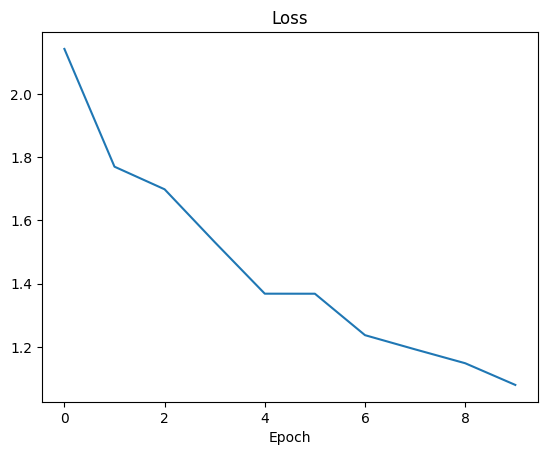

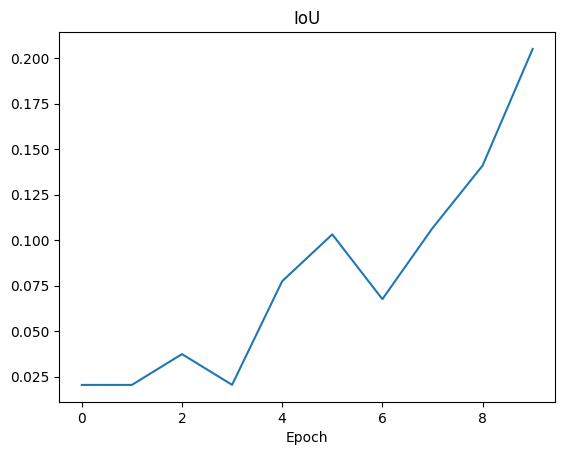

In [45]:
best = max(experiments, key=lambda x: x['iou'])
plt.plot(best['history']['train_loss']); plt.title('Loss'); plt.xlabel('Epoch'); plt.show()
plt.plot(best['history']['val_iou']); plt.title('IoU'); plt.xlabel('Epoch'); plt.show()

Оглашаю функцию визуализации сегментации и вывожу результат лучшей модели

In [46]:
def viz_seg(model, loader, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for i, (X, y) in enumerate(loader):
            if i >= num_samples: 
                break
                
            X, y = X.to(device), y.to(device)
            out = model(X)
            if isinstance(out, dict):
                out = out['out']
            pred = out.argmax(dim=1)

            img = X[0].permute(1,2,0).cpu().numpy()
            img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])

            axes[i, 0].imshow(np.clip(img, 0, 1))
            axes[i, 0].set_title('Input')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(y[0].cpu().numpy(), cmap='tab20')
            axes[i, 1].set_title('GT')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred[0].cpu().numpy(), cmap='tab20')
            axes[i, 2].set_title('Pred')
            axes[i, 2].axis('off')

    for j in range(i+1, num_samples):
        for ax in axes[j]:
            ax.axis('off')
            ax.set_visible(False)
            
    plt.tight_layout()
    plt.show()

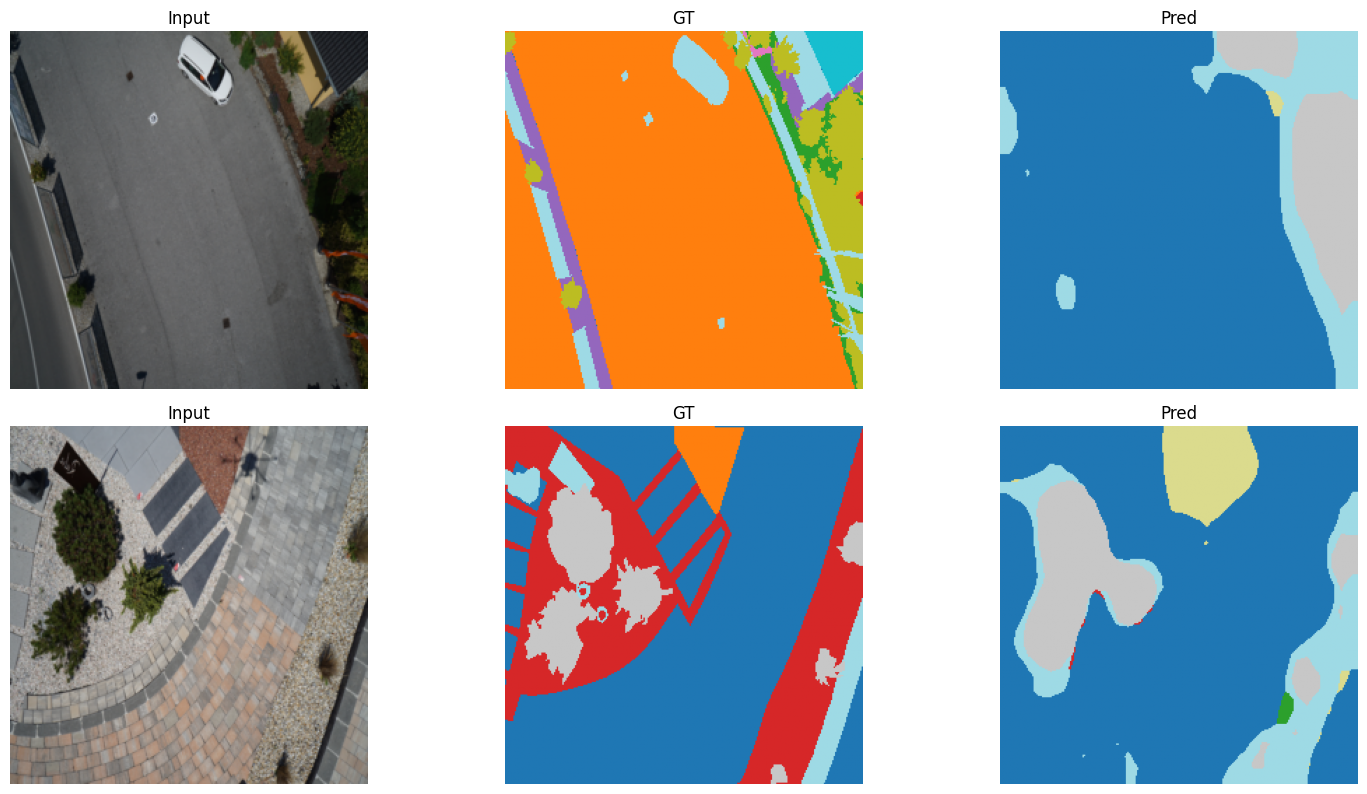

In [47]:
viz_seg(best['model'], val_ld, device, num_samples=3)